随机森林模型训练
数据加载成功：
X_train: (891, 35)
y_train: (891,)
X_test: (418, 35)

【数据检查】
训练集是否有缺失值: 0
测试集是否有缺失值: 1

数据类型分布:
bool       27
int64       6
float64     2
Name: count, dtype: int64

3. 基线随机森林
基线随机森林 CV 准确率: 0.8047 (±0.0337)
训练集准确率: 0.9843
⚠️ 可能存在轻微过拟合，需要调参

4. 随机森林调参

4.1 优化树的数量...
最佳 n_estimators: 100
对应 CV 准确率: 0.8047

4.2 优化树的深度...
最佳 max_depth: 10
对应 CV 准确率: 0.8283

4.3 优化节点分裂参数...
最佳 min_samples_split: 5
对应 CV 准确率: 0.8316

4.4 优化叶子节点参数...
最佳 min_samples_leaf: 2
对应 CV 准确率: 0.8339

5. 训练最终模型
最佳参数组合:
  n_estimators: 100
  max_depth: 10
  min_samples_split: 5
  min_samples_leaf: 2
  random_state: 42
  n_jobs: -1

最终模型 CV 准确率: 0.8339 (±0.0262)
训练集准确率: 0.8911

6. 特征重要性分析

Top 15 最重要的特征:
               feature  importance
1                  Sex    0.160625
9             Title_Mr    0.107202
5                 Fare    0.102321
2                  Age    0.072907
31    SexPclass_male_3    0.053628
0               Pclass    0.053104
26  SexPclass_female_1    0.048155
27  SexPclass_female_2   

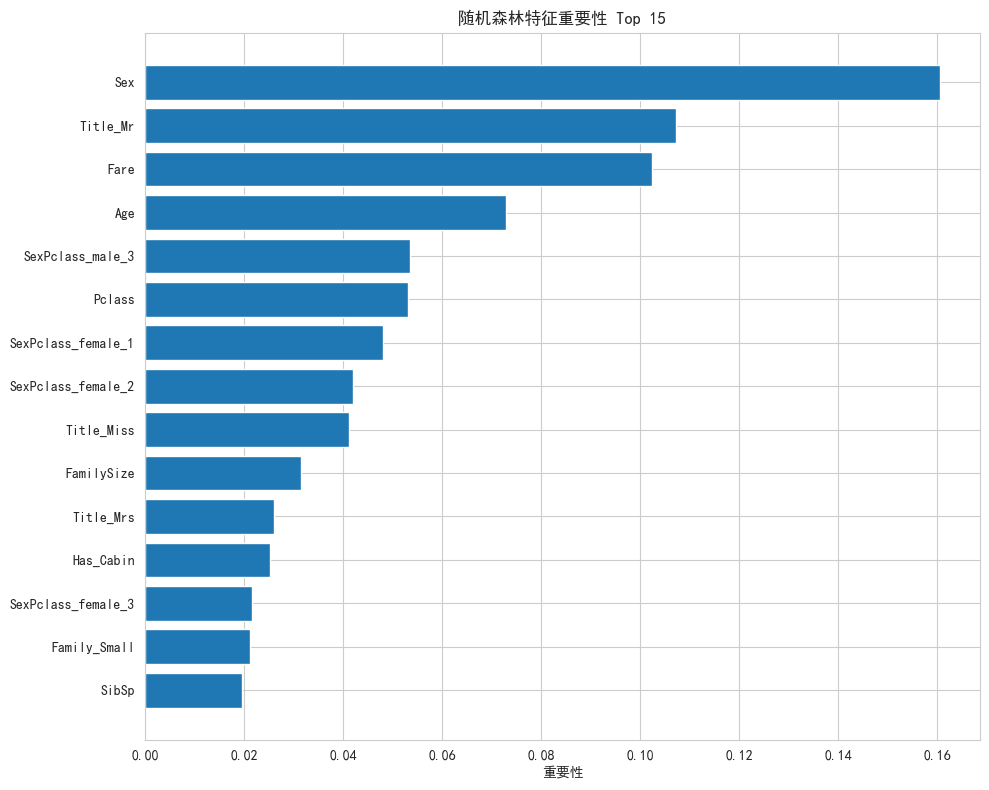


前5个特征累积重要性: 49.67%
前10个特征累积重要性: 71.26%

7. 生成提交文件
✅ 提交文件已生成: D:\python专业版项目\Data science\competitions\titanic\submissions\rf_20260409_111651.csv

预测结果分布:
Survived
0    266
1    152
Name: count, dtype: int64
幸存比例: 36.36%


In [1]:


import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.metrics import accuracy_score
from datetime import datetime
import matplotlib.pyplot as plt
import warnings
import os

warnings.filterwarnings('ignore')

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

print("=" * 50)
print("随机森林模型训练")
print("=" * 50)



processed_dir = r'D:\python专业版项目\Data science\competitions\titanic\data\processed'

X_train = pd.read_csv(os.path.join(processed_dir, 'X_train.csv'))
y_train = pd.read_csv(os.path.join(processed_dir, 'y_train.csv')).squeeze()
X_test = pd.read_csv(os.path.join(processed_dir, 'X_test.csv'))

# 加载原始测试数据（用于获取PassengerId）
test_raw = pd.read_csv(r'D:\python专业版项目\Data science\competitions\titanic\data\raw\test.csv')

print(f"数据加载成功：")
print(f"X_train: {X_train.shape}")
print(f"y_train: {y_train.shape}")
print(f"X_test: {X_test.shape}")


print("\n【数据检查】")
print(f"训练集是否有缺失值: {X_train.isnull().sum().sum()}")
print(f"测试集是否有缺失值: {X_test.isnull().sum().sum()}")

# 检查数据类型
print(f"\n数据类型分布:")
print(X_train.dtypes.value_counts())

# 如果有缺失值，用训练集均值填充
if X_train.isnull().sum().sum() > 0:
    X_train.fillna(X_train.mean(), inplace=True)
if X_test.isnull().sum().sum() > 0:
    X_test.fillna(X_train.mean(), inplace=True)




# 创建基线模型
rf_base = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

# 5折交叉验证
base_scores = cross_val_score(rf_base, X_train, y_train, cv=5)
print(f"基线随机森林 CV 准确率: {base_scores.mean():.4f} (±{base_scores.std():.4f})")

# 训练并查看训练集准确率
rf_base.fit(X_train, y_train)
train_pred = rf_base.predict(X_train)
train_acc = accuracy_score(y_train, train_pred)
print(f"训练集准确率: {train_acc:.4f}")

# 判断过拟合程度
if train_acc - base_scores.mean() > 0.05:
    print("可能存在轻微过拟合，需要调参")
else:
    print("过拟合程度可接受")



# 4.1 先调 n_estimators（树的数量）
print("\n4.1 优化树的数量...")
param_n = {'n_estimators': [100, 200, 300, 400, 500]}
grid_n = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_n, cv=5, scoring='accuracy'
)
grid_n.fit(X_train, y_train)
best_n = grid_n.best_params_['n_estimators']
print(f"最佳 n_estimators: {best_n}")
print(f"对应 CV 准确率: {grid_n.best_score_:.4f}")

# 4.2 调 max_depth（树的深度）
print("\n4.2 优化树的深度...")
param_depth = {'max_depth': [3, 5, 7, 10, 15, 20, None]}
grid_depth = GridSearchCV(
    RandomForestClassifier(n_estimators=best_n, random_state=42, n_jobs=-1),
    param_depth, cv=5, scoring='accuracy'
)
grid_depth.fit(X_train, y_train)
best_depth = grid_depth.best_params_['max_depth']
print(f"最佳 max_depth: {best_depth}")
print(f"对应 CV 准确率: {grid_depth.best_score_:.4f}")


print("\n4.3 优化节点分裂参数...")
param_split = {'min_samples_split': [2, 5, 10, 15, 20]}
grid_split = GridSearchCV(
    RandomForestClassifier(
        n_estimators=best_n,
        max_depth=best_depth,
        random_state=42,
        n_jobs=-1
    ),
    param_split, cv=5, scoring='accuracy'
)
grid_split.fit(X_train, y_train)
best_split = grid_split.best_params_['min_samples_split']
print(f"最佳 min_samples_split: {best_split}")
print(f"对应 CV 准确率: {grid_split.best_score_:.4f}")


print("\n4.4 优化叶子节点参数...")
param_leaf = {'min_samples_leaf': [1, 2, 4, 6, 8]}
grid_leaf = GridSearchCV(
    RandomForestClassifier(
        n_estimators=best_n,
        max_depth=best_depth,
        min_samples_split=best_split,
        random_state=42,
        n_jobs=-1
    ),
    param_leaf, cv=5, scoring='accuracy'
)
grid_leaf.fit(X_train, y_train)
best_leaf = grid_leaf.best_params_['min_samples_leaf']
print(f"最佳 min_samples_leaf: {best_leaf}")
print(f"对应 CV 准确率: {grid_leaf.best_score_:.4f}")


print("\n" + "=" * 50)
print("5. 训练最终模型")
print("=" * 50)

# 用找到的最佳参数
best_params = {
    'n_estimators': best_n,
    'max_depth': best_depth,
    'min_samples_split': best_split,
    'min_samples_leaf': best_leaf,
    'random_state': 42,
    'n_jobs': -1
}

print("最佳参数组合:")
for k, v in best_params.items():
    print(f"  {k}: {v}")

# 创建最终模型
rf_final = RandomForestClassifier(**best_params)

# 交叉验证最终分数
final_scores = cross_val_score(rf_final, X_train, y_train, cv=5)
print(f"\n最终模型 CV 准确率: {final_scores.mean():.4f} (±{final_scores.std():.4f})")

# 在整个训练集上训练
rf_final.fit(X_train, y_train)

# 训练集准确率
train_pred = rf_final.predict(X_train)
train_acc = accuracy_score(y_train, train_pred)
print(f"训练集准确率: {train_acc:.4f}")


print("\n" + "=" * 50)
print("6. 特征重要性分析")
print("=" * 50)

# 获取特征重要性
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_final.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 15 最重要的特征:")
print(feature_importance.head(15))

# 可视化
plt.figure(figsize=(10, 8))
plt.barh(feature_importance.head(15)['feature'],
         feature_importance.head(15)['importance'])
plt.xlabel('重要性')
plt.title('随机森林特征重要性 Top 15')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# 累积重要性
feature_importance['cumulative'] = feature_importance['importance'].cumsum()
print(f"\n前5个特征累积重要性: {feature_importance.iloc[:5]['cumulative'].iloc[-1]:.2%}")
print(f"前10个特征累积重要性: {feature_importance.iloc[:10]['cumulative'].iloc[-1]:.2%}")

print("\n" + "=" * 50)
print("7. 生成提交文件")
print("=" * 50)

# 预测测试集
test_pred = rf_final.predict(X_test)

# 创建提交文件
submission = pd.DataFrame({
    'PassengerId': test_raw['PassengerId'],
    'Survived': test_pred
})

# 保存文件
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
submission_path = rf'D:\python专业版项目\Data science\competitions\titanic\submissions\rf_{timestamp}.csv'
submission.to_csv(submission_path, index=False)

print(f"提交文件已生成: {submission_path}")


print(f"\n预测结果分布:")
print(submission['Survived'].value_counts())
print(f"幸存比例: {submission['Survived'].mean():.2%}")
